In [3]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from dataclasses import replace
from scipy.ndimage import gaussian_filter1d
import importlib
import datetime as _dt
from astropy.io import fits
import os

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import run_extract, read_galaxy_fits, run_stack, measure, plotting, core, stack
from utils_lya_halo.extract import build_run_table, build_bad_fiber_mask
from utils_lya_halo import PipelineConfig

LYA_REST = PipelineConfig.LYA_REST

In [11]:
N = None
core_radius = 3.5 #Arcsec
catalog_path = "catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits"
field = "AEGIS"

cfg2 = replace(cfg, 
    num_gal         = N,
    field           = field,
    catalog         = "MOSDEF",
    catalog_path    = catalog_path,
    bins            = [0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    bin_mode        = "virial",
    mask_method     = "segmap",
    id_col          = "ID",
    bg_inner_arcsec = 57.0,
    bg_outer_arcsec = 63.0,
    min_bg_fibers   = 25,
    fiber_combine_method = "biweight",
    rest_delta      = 0.2,
    rest_wave_min   = 1100,
    rest_wave_max   = 1700,
    rest_density    = True,
    cut_radial_bin  = 5,
    min_good_wave   = 100,
    combine_wave_block = 16,
    line_window     = [LYA_REST-4, LYA_REST+4],
    n_bootstrap     = 1000)

# The Extraction

In [12]:
catalog_keep = Table.read('catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits', format='fits')
catalog_keep[:5]

INDEX,FIELD,CATALOG,ID,ID_V21,ID_V41,MASKNAME,SLITOBJNAME,RA,DEC,z,Z_QUAL,HA_FLUX,HA_FLUX_ERR,HA_FWHM,HA_FWHM_ERR,HB_FLUX,HB_FLUX_ERR,HB_FWHM,HB_FWHM_ERR,HG_FLUX,HG_FLUX_ERR,HG_FWHM,HG_FWHM_ERR,HD_FLUX,HD_FLUX_ERR,HD_FWHM,HD_FWHM_ERR,OII3727_FLUX,OII3727_FLUX_ERR,OII3727_FWHM,OII3727_FWHM_ERR,OII3730_FLUX,OII3730_FLUX_ERR,OII3730_FWHM,OII3730_FWHM_ERR,OIII4364_FLUX,OIII4364_FLUX_ERR,OIII4364_FWHM,OIII4364_FWHM_ERR,OIII4960_FLUX,OIII4960_FLUX_ERR,OIII4960_FWHM,OIII4960_FWHM_ERR,OIII5008_FLUX,OIII5008_FLUX_ERR,OIII5008_FWHM,OIII5008_FWHM_ERR,OI6302_FLUX,OI6302_FLUX_ERR,OI6302_FWHM,OI6302_FWHM_ERR,NII6550_FLUX,NII6550_FLUX_ERR,NII6550_FWHM,NII6550_FWHM_ERR,NII6585_FLUX,NII6585_FLUX_ERR,NII6585_FWHM,NII6585_FWHM_ERR,SII6718_FLUX,SII6718_FLUX_ERR,SII6718_FWHM,SII6718_FWHM_ERR,SII6733_FLUX,SII6733_FLUX_ERR,SII6733_FWHM,SII6733_FWHM_ERR,NEIII3870_FLUX,NEIII3870_FLUX_ERR,NEIII3870_FWHM,NEIII3870_FWHM_ERR,NEIII3969_FLUX,NEIII3969_FLUX_ERR,NEIII3969_FWHM,NEIII3969_FWHM_ERR,NIIHA,NIIHA_ERR,MASS_50,MASS_16,MASS_84,SFR_50,SFR_16,SFR_84,SSFR_50,SSFR_16,SSFR_84,AV_50,AV_16,AV_84,AGE_50,AGE_16,AGE_84,TAU_50,TAU_16,TAU_84,CHI2,ZFAST,EBV_STAR_16,EBV_STAR_50,EBV_STAR_84,HA_SN,HA_FLAG,HB_SN,HB_FLAG,HG_SN,HG_FLAG,HD_SN,HD_FLAG,OII3727_SN,OII3727_FLAG,OII3730_SN,OII3730_FLAG,OIII4364_SN,OIII4364_FLAG,OIII4960_SN,OIII4960_FLAG,OIII5008_SN,OIII5008_FLAG,OI6302_SN,OI6302_FLAG,NII6550_SN,NII6550_FLAG,NII6585_SN,NII6585_FLAG,SII6718_SN,SII6718_FLAG,SII6733_SN,SII6733_FLAG,NEIII3870_SN,NEIII3870_FLAG,NEIII3969_SN,NEIII3969_FLAG,O3,O3_ERR,O32,O32_ERR,EBV_NEB_16,EBV_NEB_50,EBV_NEB_84,FLUX_RADIUS,A_IMAGE,B_IMAGE,THETA_J2000,KRON_RADIUS,FWHM_IMAGE,CLASS_STAR,F_F160W,E_F160W,F_F814W,E_F814W,F_F606W,E_F606W,F_G,E_G,F_R,E_R,F_V,E_V,F_IRAC1,E_IRAC1,IRAC1_CONTAM,F_IRAC2,E_IRAC2,IRAC2_CONTAM,F_IRAC3,E_IRAC3,IRAC3_CONTAM,F_IRAC4,E_IRAC4,IRAC4_CONTAM,USE_PHOT,STAR_FLAG,PHOT_FLAGS,Z_SPEC,TOT_COR,SKELTON_MATCH,BA,INCL_DEG,GALFIT_FLAG_F160W,GALFIT_MAG_F160W,GALFIT_MAG_ERR_F160W,RE_F160W,RE_ERR_F160W,N_F160W,N_ERR_F160W,Q_F160W,Q_ERR_F160W,PA_F160W,PA_ERR_F160W,SN_F160W,VDW_MATCH_F160W,GALFIT_FLAG_F125W,GALFIT_MAG_F125W,GALFIT_MAG_ERR_F125W,RE_F125W,RE_ERR_F125W,N_F125W,N_ERR_F125W,Q_F125W,Q_ERR_F125W,PA_F125W,PA_ERR_F125W,SN_F125W,VDW_MATCH_F125W,RE_BEST,RE_BEST_SRC,Q_BEST,Q_BEST_SRC,RE_CIRC_BEST,MAG_G,MAG_R,MAG_V,MAG_F606W,MAG_F814W,MAG_F160W,GR_COLOR,Z_SECURE,Z_INWINDOW,BEST_LINE_SN,LINE_SN_OK,COORDS_OK,SAMPLE,HAS_DUP_0p5AS,DUP_DROP,BLEND_DROP,BLEND_MERGE,KEEP,XRAY_MATCH,XRAY_SEP_AS,XRAY_NAME,XRAY_FLUX_B,XRAY_SIG,AGN_XRAY,NIIHA_OK,BPT_O3HB,BPT_N2HA,AGN_OPT_USABLE,AGN_OPT,DONLEY_X,DONLEY_Y,AGN_IR_USABLE,AGN_IR,AGN_FLAG,CLEAN,MEX_O3HB,AGN_MEX,MEX_INTERMED,AGN_MEX_USABLE,AGN_MEX_APPLIED,VALID,EBV
int64,bytes6,bytes6,int64,int64,int64,bytes8,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [13]:
#Obtains one PSF-weighted core spectrum per galaxy
#Takes ~1 hour

Spec, Err, wave_obs, catalog, extras = core.extract_core_spectra(cfg2, 
    core_radius=core_radius, 
    return_extras=True,
    save_background=True)

Loaded AEGIS: 141 exposures, 34944 fibers, 1036 wavelength pixels
Same RA and bad_fiber_mask shape? True
Bad fibers: 500106
Good fibers: 4426998
Fraction bad: 0.102
Fibers off mask footprint: 0.000%


extract_core:   0%|          | 0/244 [00:00<?, ?it/s]

# Initial Lya Core Measurement

In [14]:
results = core.run_core_hierarchical(
    Spec, Err, wave_obs, catalog,
    detect_snr=2.0,
    n_sigma_emit=1.0,
    n_sigma_absorb=1.0,
    red_offset=0.0,                          # window now centered on 1215.67+0.5, ±hw
    hw=4,                                  # half-width of the (now symmetric) B window
    cont_bounds=cfg.cont_bounds,   # tune the continuum sidebands here
    cont_method="poly", cont_order=1,
    class_stat="mf",
    escape=True,
    flux_for_escape="mf",
    ew_threshold=20.0, ew_flux="mf", mag_col="auto",
)

measure_core_hier:   0%|          | 0/244 [00:00<?, ?it/s]

/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/hom


run_core_hierarchical: 121/244 detections (S/N_mf >= 3.0); 100 with a usable Gaussian position.
  labelled on sn_B with emit >= 2sigma, absorb <= -2sigma (red_offset=0):
  labels: LAE=28 (EW_0 >= 20 A)  emitter=108  absorber=14  null=94   [52 galaxies had no continuum EW]


/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))
/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))


In [15]:
core.write_core_hier_fits("7-5-26-core_extraction_egs.fits",
                          Spec,
                          Err,
                          wave_obs,
                          catalog,
                          results,
                          extras=extras,
                          overwrite=True)

wrote hierarchical core FITS -> 7-5-26-core_extraction_egs.fits  (244 galaxies)  [+background]


'7-5-26-core_extraction_egs.fits'

In [ ]:
import numpy as np
from astropy.table import Table

def diagnose_missing_ew(catalog, results, *, z_col="Z",
                        mag_g_col="MAG_G", mag_r_col="MAG_R",
                        auto_z_switch=2.3, mag_min=10.0, mag_max=40.0,
                        id_col="ID"):
    """
    Explain every 'no continuum EW' (NaN ew_rest) galaxy: which broadband band it
    used, the raw magnitude value, whether that value is a sentinel vs simply
    missing, and whether the galaxy was a Lya DETECTION (a would-be LAE we can't
    classify) or a non-detection. Returns an astropy Table of the offenders.
    """
    ngal = len(catalog)
    ew   = np.asarray(results["ew_rest"], float)
    miss = ~np.isfinite(ew)
    z    = np.asarray(catalog[z_col], float)
    mg   = (np.asarray(catalog[mag_g_col], float) if mag_g_col in catalog.colnames
            else np.full(ngal, np.nan))
    mr   = (np.asarray(catalog[mag_r_col], float) if mag_r_col in catalog.colnames
            else np.full(ngal, np.nan))
    band     = np.where(z < auto_z_switch, "g", "r")
    mag_used = np.where(z < auto_z_switch, mg, mr)
    detected = np.asarray(results.get("detected", np.zeros(ngal, bool)), bool)

    reason = np.full(ngal, "", dtype=object)
    reason[~np.isfinite(mag_used)]                                  = "mag missing/masked"
    reason[np.isfinite(mag_used) & ~((mag_used > mag_min) &
                                     (mag_used < mag_max))]         = "mag sentinel/out-of-range"

    ids = (np.asarray(catalog[id_col]) if id_col in catalog.colnames
           else np.arange(ngal))
    tbl = Table(dict(
        row=np.where(miss)[0], id=ids[miss], z=z[miss],
        band=band[miss], mag_used=mag_used[miss],
        reason=reason[miss].astype(str), detected=detected[miss],
        sn_mf=np.asarray(results.get("sn_mf", np.full(ngal, np.nan)))[miss],
    ))
    print(f"no-continuum-EW galaxies: {miss.sum()} / {ngal}")
    print(f"  used g-band: {(tbl['band']=='g').sum()}   used r-band: {(tbl['band']=='r').sum()}")
    print(f"  of these, DETECTIONS (real line, no continuum -> unclassifiable LAEs): "
          f"{tbl['detected'].sum()}")
    for r in sorted(set(tbl['reason'])):
        print(f"  reason '{r}': {(tbl['reason']==r).sum()}")
    return tbl

In [ ]:
missing = diagnose_missing_ew(catalog, results, z_col=cfg2.z_col)
missing[:10].pprint(max_width=-1)

# visualize: where do the "used" broadband mags sit? sentinels pile up outside 10-40.
z = np.asarray(catalog[cfg2.z_col], float)
mag_used = np.where(z < 2.3,
                    np.asarray(catalog["MAG_G"], float),
                    np.asarray(catalog["MAG_R"], float))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mag_used[np.isfinite(mag_used)], bins=60, color="C0", alpha=0.8)
ax.axvspan(10, 40, color="C2", alpha=0.12, label="valid range (EW computed)")
ax.set_xlabel("broadband magnitude used for continuum"); ax.set_ylabel("galaxies")
ax.legend(); plt.show()

# Extraction Visualization

In [61]:
# load the field WITH the PSF grid (same loader the extraction uses)
vdfi = core.load_field_with_psf(cfg2)
catalog = build_run_table(cfg2)
bad = build_bad_fiber_mask(cfg2, vdfi)

Loaded AEGIS: 141 exposures, 34944 fibers, 1036 wavelength pixels


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


Same RA and bad_fiber_mask shape? True
Bad fibers: 498264
Good fibers: 4428840
Fraction bad: 0.101


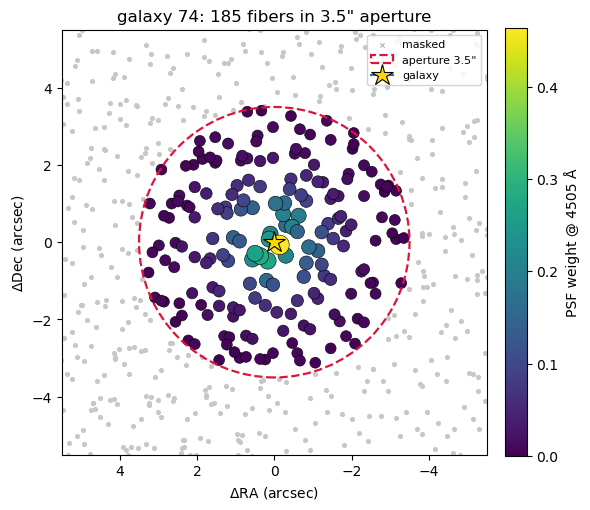

In [42]:
# overlay for one galaxy — dots colored/sized/alpha'd by PSF weight,
# dashed circle = extraction aperture, gold star = galaxy center
ax, geom = core.plot_fiber_overlay(vdfi, catalog, gal_index=74,
                                   bad_fiber_mask=bad, core_radius=core_radius)